# Step Numero UNO:

### 1. Why systems engineering matters for an AI engineer:

A beginner often imagines an AI application as a direct path from user input to a model and then to an output. In production, the model is only one component inside a network of interfaces, policies, stores, tools, humans, and operational controls.


Prototype mental model
```
User Input -> LLM or ML model -> Output
```

# Production mental model:

```
USER
    -> Frontend
    -> Authentication
    -> Application service.
    -> AI orchestrator
        -> LLM.
        -> Retrieval.
        -> Tools.
        -> Memory.
        -> Databases.
        -> External APIs.
        -> Safety checks.
    -> Validation.
    -> Logging and evaluation.
    -> Response.
```
A model may perform well on benchmark while the full product fails. Retrieval may return irrelevant evidence. An API may time out. A duplicated tool call may create a duplicated transaction. Context may overflow. A response may violate a schema. Latency or cost may make the product unusable.

`central lesson: Systems engineering teaches you to design the entire mechanism, not merely the intelligent component.`

```Model-focused thinking-> Application-focused thinking -> System-focused thinking -> Socio-technical thinking```

# 2. What is systems Engineering?

Systems engineering is the structured discipline of designing, integrating, verifying, operating, and evolving complex systems throughout their lifecycle. It connects purpose, requirements, architecture, implementation, evidence, operation, risk, and change.

```
1. What problem are we solving?
2. Who are the stakeholders?
3. What must the system do?
4. Under what constraints must it operate?
5. Which components and interfaces are required?
6. How will failures be detected, contained, and recovered?
7. How will we prove that the system works?
8. How will the system operate, evolve, and eventually retire?
```

System =
Components
* Interfaces
* Relationships
* Constraints.
* Environment
* Feedback.
* Purpose.

`An LLM is a component. A production AI assistant is a system. An autonomous robot is a cyber-physical system. An organization using agents, databases, people, procedures, and business rules is a socio-techincal system.`

# 3. System engnineering=, sustem design, and software engineering.


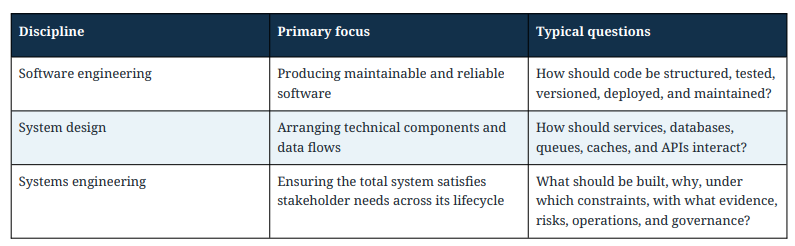

```
Practical Relationship:
Software engineering tells you how to build code well. System design tells you how to arrange technical components. Systems engineering tells you what should be built, why it should be built, how the whole system should behave, and how you will know it succeeds.
```
# 4. The cental mental shift:

The primary question is not, "Which model should I use?" It is, "What complete system will reliably achieve the user objective under real-world constraints?

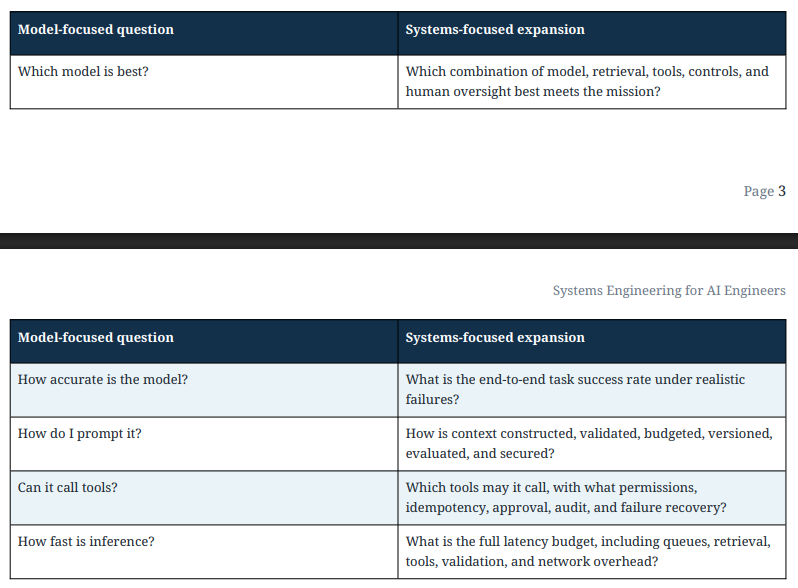 

Model choice remains important, but it becomes one trade-off inside a larger architecture.


# 5. The seven foundations of systems thinking:

5.1 Purpose :
Every system exists to achieve an objective. Replace vague goals such as "build a chatbot" with measurable mission statements such as "reduce routine support resolution time by 35% without increasing incorrect resolutions."


5.2 System Boundary:

Define what is inside the system, what is outside, and where responsibility changes. Boundaries reveal external actors, trust zones, dependencies, and ownership gaps.

5.3 Components and interfaces:

Components perform functions; interfaces define how they cooperate. A stable interface can make a model, database, or provider replaceable. A week inteface spreads fragility.


5.4 Interactions :

Components may be individually correct yet collectively fail. For example, retrieving too many documents can overflow context and hide the most important evidence.

5.5 Feedback loops:
Outputs become signals that influence future behaviour. Feedback may stabilize quality or amlify errors. Alwyas ask what signals drive the loop and whether the loop can become self-reinforcing.

5.6 Emergent behaviour:

Interactions among agents, retries, recommendations, users, and shared resources can produce unexpected system-level behaviour.

5.7 Constraints and trade-offs

Engineering is the art of satisfying a mission with limited cost,time, compute, data, safety margin, and human attention. There is rarely a universally best architecture.


```
Interaction Failure:

Retriever returns 20 documents:

-> Prompt becomes too large.
-> Critical instructions move into the middle.
-> Model misses important  evidence.
-> Answer quality declines.
```
 
```
System principle:

Local correctness does not guarantee global correctness
```

# 6. Functional and non-functional requirements:

6.1 Functional requirements:

Functional requirements describe what the system must do. Good requirements use clear verbs, defined subjects, and testable outcomes.

* The system shall answer questions using approved documents.
* The system shall generate citations linked to the retrieved evidence.
* The system shall request reviewer approval before high-risk write actions.
* The system shall preserve thread-scoped conversation state.

6.2 Non-functional requirements:

Non-functional requirements describe how well teh system must do. Goos requirements use clear verbs, defined subjects, and testable outcomes.

* The system shall answer question using approved documents.
* The system shall citations linked to the retrieved evidence.
* The system shall request reviewer approval before high-risk write actions.
* The system shall preserve thread-scoped conversation state.

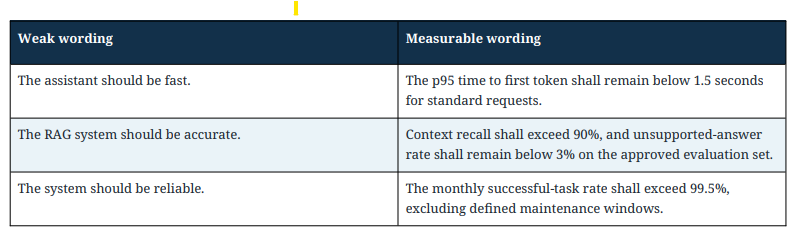 

# 7. The system lifecycle:


```Need -> Requirements -> Architecture -> Detailed design -> Implementation -> Integration -> Verification -> Deployment -> Operation -> Monitoring -> Evolution -> Retirement```


# Problem discovery:

Understand the current workflow, users, pain points, error costs, available data, legal constraints, and operational environment.

# Requirements Definition:
Translate needs into measureable behaviors and thresholds.

# Architecture:

Select boundaries, components, communication styles, stores, providers, trust zones, and fallback strategies.


# Implementation and integration 
Build components and expose interface mismatches, latency accumulation, inconsistent identifiers, and retry interactions.

# Verification and integration:

Build components and expose interface mismatches, latency accumulation, inconsistent identifiers, and retry interactions.

# Operations:

Monitor health, respond to incidents, control versions, roll back changes, manage cost, and support users. 

# Operations:

Monitor health, respond to incidents, control versions, roll back changes, manage cost, and support users.


# Evolution and retirement:
Adapt to model, data, policy, security, and product changes, while planning migration and data disposal.


`
Verification VS validation:
Verification asks, "Did we build the system according to specification?" Validation asks,"Did we build the correct system for the real user need?"
`

# 8. The V-model for AI systems:

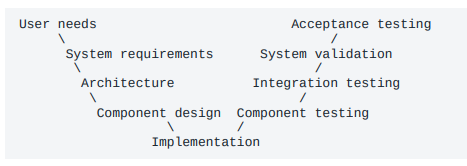 

# Design Rule:
`
Every important requirement should have corresponding evidence or a test.
`

# 9. Decomposition and abstraction:

### 9.1 Decomposition:

Decomposition breaks a large system into subsystems with clear responsibilities, interfaces, owners, failure, behaviour, and test strategies.

1. Input and experience subsystem.
2. Identity and authorization subsystem.
3. Document-ingestion subsystem.
4. Retrieval subsystem.
5. Agent- Orchestation subsystem.
6. Model-inference subsystem.
7. Persistence subsystem.
8. Evaluation Subsystem.
9. Safety Subsystem.
10. Observability and operations subsystem.


# 9.2 Abstraction Levels:

```
Mission: Reduce support workload

-> Capabiltiy: Answer routine questions and escalte uncertainty.
-> Architecture: RAG + workflow + human review+ anaytics
-> Component design: Hubrid search, reranker, approval node;
-> Implementation: Python, APIs, schemas, queries, tests

```
A strong engineer can zoom out to mission and constraints, then zoom in to implementation details witout losing the connection between them.

# 10. Coupling, cohesion, interfaces, and contracts:

10.1 Cohesion and coupling:

High cohesion means the responsibilities inside a component belong together. Low coupling means components depend on stable contracts rather than each other's internal details.

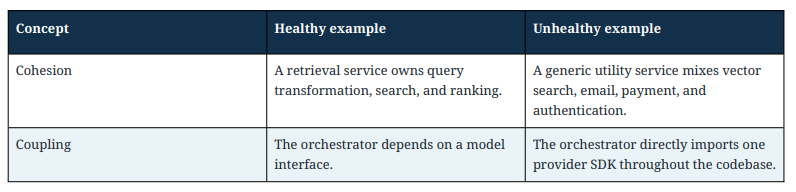 

```
Desired Structure:
High cohesion inside components plus low coupling between components.

```

10.2 Interfaces and contracts:

A contract should define valid inputs, outputs, errors,timeouts, size limits, versions, ownership, and security expectations.

```
SearchRequest:
- query: str
- top_k: int
- filters: dict

SearchResult:
- document_id: str
- content: str
- score: float
- metadata: dict
```

When downstream systems require precision, treat LLM output as untrusted data. Use typed tool schemas, JSON schemas, Pydantic validation, and contract tests.

# 11. System state, control flow, and data flow:

11.1 State:

State is information that persists across operations: sessions, messages, workflow progress, tool results, pending approvals, model versions, and job status.

* `Statless`: Each request is independent.
* `Stateful`: A request depends on previous information and therefore creates consistency, privacy, synchronization, migration, and recovery concerns.


`State Questions`: Where does state live? Who owns it? How long is it retained? What  happens when concurrent operations update it? Can it be reconstructed, migrated, and deleted?


11.2 Data flow versus control flow:

Data Flow:

` PDF -> Parsed text -> Chunks -> Embeddings -> Retrieved context -> Answer `

```
Control Folow:

Request:
-> Is retrieval required?
-> Yes: retrieve.
-> No: Answer directly.

Agentic systems are challenging because both data flow and control flow can be dynamic. Graph-based orchestration makes control transitions explicit while state carries data.
```


# 12. Deterministic and probabilistic components:

Traditional software aims for deterministic behaviour. AI models are probabilistic and may vary even for similar inputs. Safe architectures surround probabilistic intelligence with deterministic controls.

```
Deterministic input validation:

-> Probabilistic model.
-> Deteministic schema validation.
-> Policy and authorization checks.
-> Controlled action.

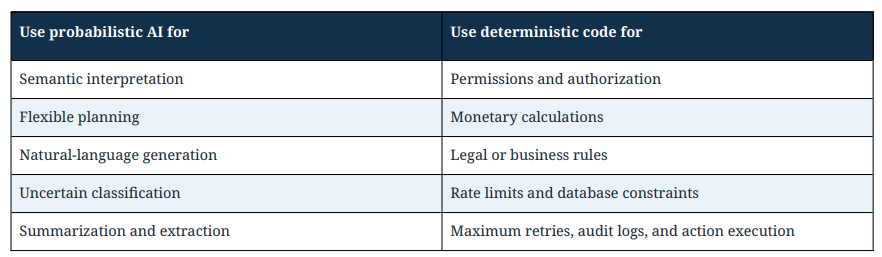 


```
Core AI systems pattern

Let models handle ambiguity. Let deterministic mechanisms enfore gurantees.
```












# 13. Reliability engineering and failure analysis:

Reliability is the probability that the system performs correctly for a defined period under defined conditions. AI reliability includes model begaviour, data quality, external services, orchestration, persistence, and human processes.


# 13.1 Failure-mode thinking:

* How can this component or interaction fail?
* How will the failure be detected?
* What is the effect on users and downstream component?
* Can the system recover automatically?
* Can recovery produce duplicate actions or additonal load?
* What evidence is required before resuming normal operation?

# 13.2 Simplified Failure Mode and Effects Ananlysis:

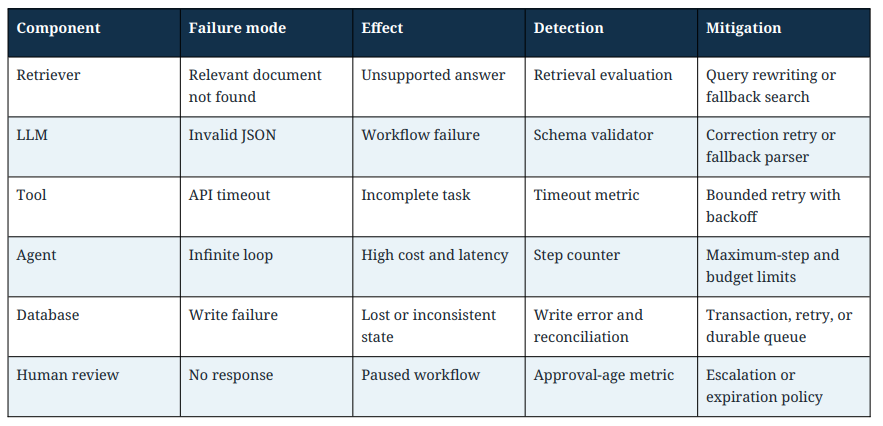

# 14. Availability, redundancy, and graceful degradation:

When several required dependencies must all work, toatl availability declines. If two independent required service are each 99% available, combined availabilty is approximately 0.99 x 0.99 = 98.01%.

Redundancy can improve reilience but also adds synchronization, cost, and operational complexity. Use it where the mission justifies the trade-off.

# Graceful degradation examples:

```
Primary LLM unavailable -> Use fallback model.
Reranker unavailble -> Use base search ranking.
Personalization unavailable -> Provide generic response.
Write tool unavailable -> Provide instructions instead of executing.
Streaming unavialable -> Return a complete response.
```
Design objective:
Failure should reduce capability in a controlled way rather than collapse the entire user journey.

# 15. Distributed systems fundamentals for AI engineers:

* 15.1 Timeouts:

Never wait indefinitely for a network dependency. Define connection, read, write, and total deadlines according to the user-facing latency budget.

* 15.2 Retries:
Use bounded attempts, error classification, exponential backoff, and random jitter. Do not retry permanent errors.

* 15.3 Idempotency:
Ensure repeated requests do not create repeated side effects. Protect payment, email, ticket, and database-write tools with unique opeation identifiers.

* 15.4 Queues:
Separate task submission from execution for long-running agents,document ingestion,media processing, and batch evaluation.

* 15.5 Backpressure:
Prevent fast producers from overwhelming slow consumers through queue limits, admission control, rate limiting, and worker scaling.

* 15.6 Eventual Consistency:
Represent intermediate states such as uploaded, parsing, embedding, indexed, ready, and failed.

* 15.7 Concurrency:

Use transactions, locks,optimistic, versioning, or atomic operations when multiple workers may update the same state.

```
CONCURRENCY FAILURE

Agent A reads remining budget: $10
Agent B reads reaminig budget: $10
Agent A spends $8
Agent B spends $8
Without atomic control, total spending becomes $16
```

# 16. Latency, throughput, capacity, and caching


* 16.1 Latency engineering:

```
Total latency approximately equals:
Network + Authentication + Retrieval + Reranking + Model queue time + Inference + Tool execution + Validation + Response transfer
```

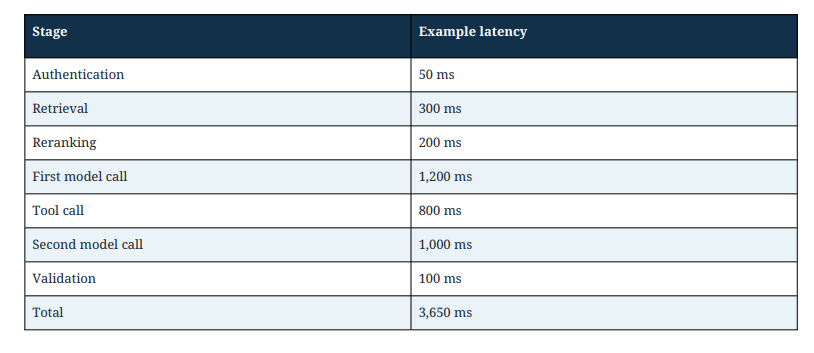

Measure end-to-end latency, time to first token, model tokens per second, queue wait time, tool latency, and p50, p95, and p99 distributions. Average latency can hide poor tail behaviour.

* 16.2 Throughput and capacity:

```
Daily model tokens =
Daily active users
x Requests per user
x Model calls per request
x Average tokens per model call
```

* 16.3 Caching:

 - Exact-response caching.
 - Semantic caching.
 - Prompt caching.
 - Embedding caching.
 - Retrieval caching.
 - Tool-result caching.

Caching raises safety and correctness questions: freshness, user isolation, private data, invalidation, and model-version dependence. The difficult problem is not storing an entry, but determining when reuse is valid.

# 17. Observability and evaluation:

* 17.1 Observability: 
Observability is the ability to understand internal system behaviour through logs, metrics, traces, and AI-specific execution records.

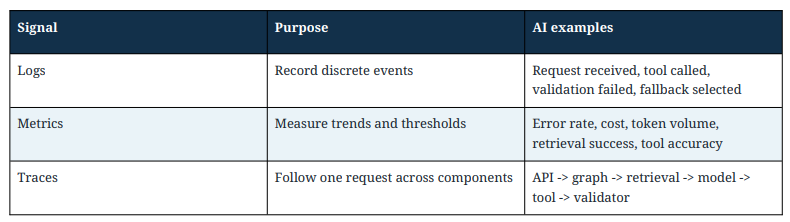 

* Prompt and model version.
* Input and output token counts.
* Retrieved document identifiers and scores.
* Tool names, arguments, results, and duration.#
* Validation and safety decisions.
* Cost, latency, retries, and user feedback.
* Complete workflow trajectory.

* 17.2 Evaluation as a systems discipline:

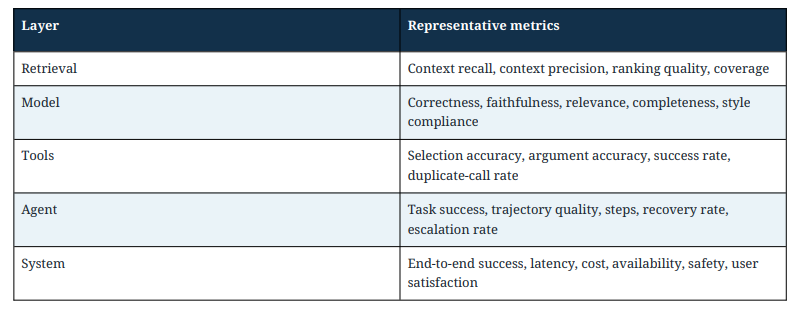

```
Evaluation principle:
Evaluate locally to diagnose. Evaluate end-to-end to validate.
```

# 18. Safety, security, and human factors:

* 18.1 Threats in AI systems:

    - Direct and idirect promt injection.
    - Data exfiltraction throug tools or rendered links.
    - Excessive agent permissions.
    - Sensitive-data leakage.
    - Cross-tenant data access.
    - Poisoned documents and malicious tool results.
    - Unsafe generated code or actions.

* 18.2 Least privilege and trust boundaries:

Each agent and tool should receive only the permissions required for its mission. User input, upload files, web pages, retrieved documents, and third-party reponses be treated as untrusted data.

```
Defence in depth:

Input validation:

-> Prompt isolation.
-> Tool permission checks.
-> Output schema validation.
-> Policy enforcement.
-> Human approval.
-> Audit logging.
```
* 18.3 Human factors:

A technically correct system may still fail because people do not trust it, alerts become exhausting, responsibilities are unclear, or the interface hides uncertainty. Human-in-loop design must define who reviews, what evidence is visible, response deadlines, disagreement handling, and audit requiremnents.

```
Human Oversight:

High-risk review should enable informed judgement, not encourage rubber-stamping.
```

# 19. A reference AI systems architecture:

1. Experiment layer.
2. API and Identity layer.
3. Orchestration layer.
4. Intelligence layer.
5. Knowledge layer.
6. Tool and integration layer.
7. Data layer.
8. Evaluation layer.
9. Safety layer.
10. Operations layer.
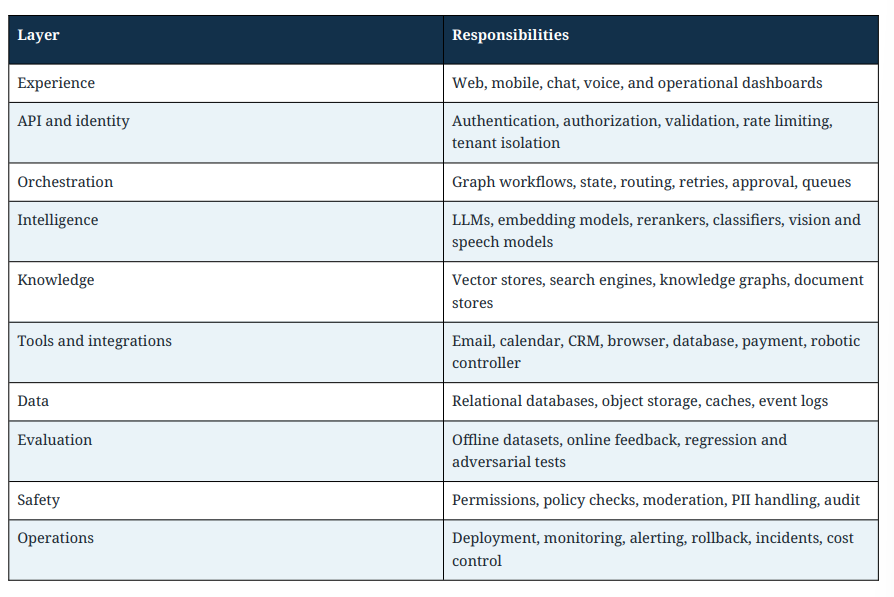

```
High-Level architecture:

Frontend:
    -> API and identity,
    -> AI orchestrator.
        -> Models.
        -> Retrieval and knowledge.
        -> Tools and integrations.
        -> State and persistence.
        -> Safety and validation.
    -> Observability, evaluation, and operations.
```

# 20. Systems engineering for robotics and embodied AI:

```
Sensors -> Perception -> World model -> Planning -> Control -> Actuators
 ^ |
 |---------------------- Physical feedback --------------------|
```

An LLM or agent may operate at a high-level task-planning layer, but it should not directly generate uncontrolled motor commands. Deterministic control, real-time constraints, safety interlocks, and verified planners reamin essential.

```
User instruction -> Language planner -> Task decomposition -> Motion planner -> Controller ->
Robot
```
* Feedback control and real-time constraints.
* Sensor fusion and state estimation.
* Simulation and digital twins.
* Motion planning and safety envelopes.
* Human-robot interaction and supervisory control.
* Graceful shutdown and fail-safe states.

```
Career Connection:

Mechatronics, digital twins, predictive maintenance, robotics, and AI agents converge naturally in embodied intelligent systems.
```

# 21. How systems engineering affects creativity:

Systems discipline can become bureacratic when applied mechanically. Applied well, it increases useful creativity by making constraints, interfaces, experiments, and failure signals explicit.

* 21.1 constraints create direction:
A precise challenge such as multilingual support, three-second latency, two-cent cost, and approval before write actions creates a more productive design space than teh vague instruction to "build a chatbot."

* 21.2 Modularity enables safe experimentation:
Well-defined components allow you to compare prompts, chunking, rerankers, models, and memory strategies without destabilizing the whole product.

* 21.3 Abstraction expands possibility:
Architecture diagrams let you explore routing, parallelism, cascades, and feedback before implementation cost hardens the design.

* 21.4 Failure analysis generates innovation:
Repeated failures often reveal new product capabilities, such as trajectory viewers, confidence routing, or recovery dashboards.

* 21.5 Systems thinking avoids local optimization:
The highest bechmark score may matter less than transparency, correct escaltion, latency, or correction affordances.

* 21.6 Divergent and Convergent thinking: Generate possibilities freely, then evaluate them against mission, cost, risk, complexity, maintainability, and user value.

```
Creative Engineering Formula:
Imagination purposes alternatives. Systems reasoning selects, combines, tests,and evolves the alternatives that can survive reality.
```

* 22. The Top Gun systems-engineering mindset:

- Mission before machinery:

    Do not begin with a framework. Begin with the capability, risk and evidence required.

- Know the entire aircraft:
    Understand what each component does, how it fails, what it depends on, and which signal reveal trouble.
- Use checklists:
    Professional checklists preserve attention for the non-routine decisions that actually require creativity.

- Train for failure:
    Simulate outages, malformed schemas, poisoned documents, duplicate calls, slow tools, and rejected approvals.

- Debrief every project:
    Document assumptions, surprises, unnecessary complexity, missing metrics, and redesign priorities.
- Maintain situational awareness:
    Know current health, cost, latency, changes, risks, and pending incidents.

- Prefer disciplined simplicity:
    Complexity is not evidence of shopistication.The simplest architecture that satisfies the mission is usually superior.

```
Design checklist:
    - Are requirements measureable?
    - Are trust boundaries documented?
    - Are timeouts and retry rules defined?
    - Are side effects idempotent?
    - Is every loop bounded?
    - Are outputs validated?
    - Can changes be rolled back?
    - Are cost and latency observable?
```



# How an AI engineer should learn systems engineering:

```
Learning Cycle:

Concept->Small Experiment->Complete system->Failure Injection->Observation->Redesign->Documentation
```

Do not learn architecture only from diagrams. Build contrasting versions, intentionally break them, and compare the operational consequences.

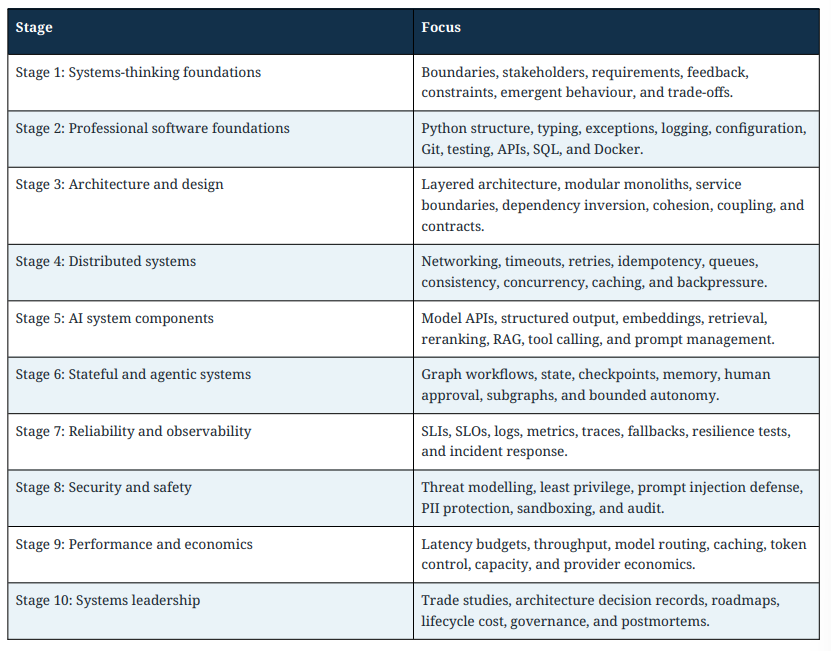

# 24. A 24-week study plan:
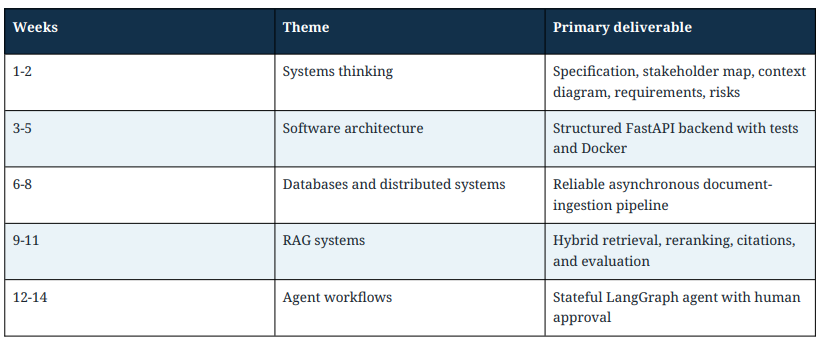 
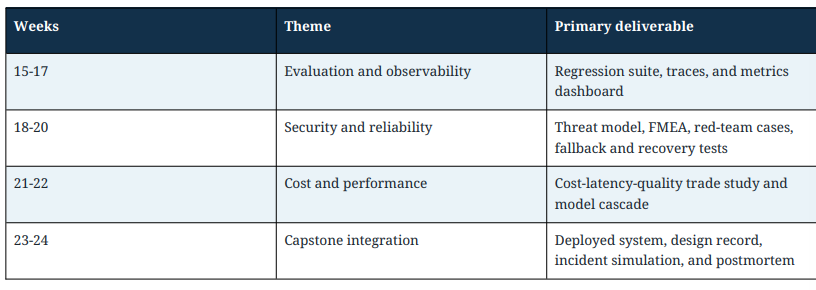

Weekly practice rhythm:

* One conceptual reading session.
* One focused implementation experiment.
* One architecture or sequence diagram.
* One failure-injection exercise.
* One written engineering debrief.

# 25. Capstone system blueprint:

Intelligent Technical Operations Assistant:

Build a system that ingests technical manuals, answers questions with citations, analyzes maintenance records, identifies possible faults, recommends troubleshooting, requests approval creating tickets, logs every action, and evaluates quality and tool use.

```
User interface:
    -> FastAPI.
    -> Authentication and rate Limiting.
    -> LangGraph orchestrator:
        -> Request classifier.
        -> Retrieval agent.
        -> Data-analysis tool.
        -> Fault-diagnosis workflow.
        -> Validation node.
        -> Human-approval node.
    -> PostgreSQL + Vector database + Object storage.
    -> Tracing + Metrics + Evaluation.
```
# Suggested engineering milestones:

1. Define mission, users, non-goals, and measureable success criteria.
2. Create a context diagram and threat model.
3. Implement document ingestion with job states and duplicate prevention.
4. Build hybrid retrieval and a retrieval evaluation set.
5. Add answer generation with citations and structured output.
6. Add tool-calling for maintence-data analysis.
7. Add deterministic policy gates and human approval for write actions.
8. Add traces, metrics, retries, timeouts, idempotency, and loop limits.
9. Add traces, metrics, cost accounting, and offline regression tests.
10. Run failure simulations and write an incident postmortem.
11. Deploy and document the architecture, decisions, risks, and limitations.

# 26. Engineering documents and design artifacts:

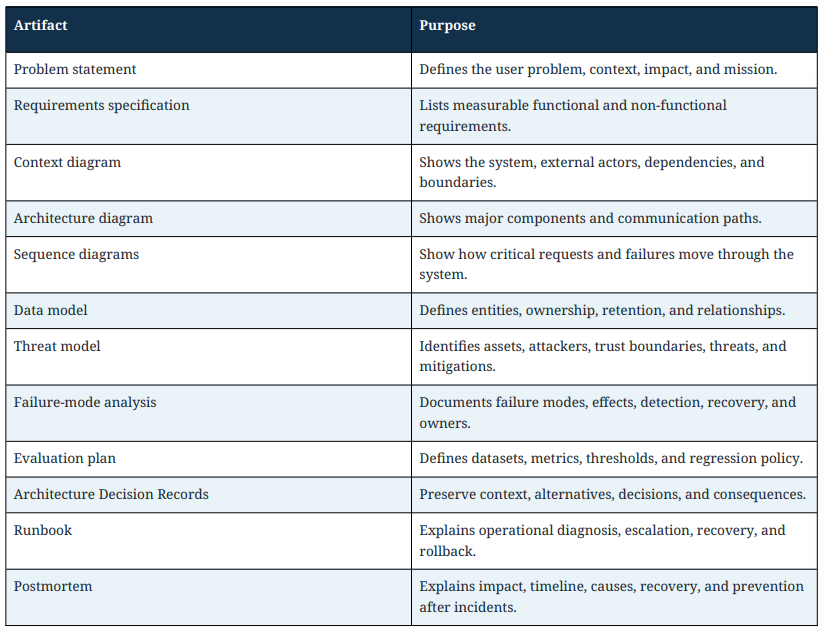 

```
Architecture Design record:
Decision: Use PostgreSQL for workflow chechpoints.
Context: Durable recovery and queryability are required.
Alternatives: In-memory storage, Redis, PostgreSQL.
Reason: Transactions, durability, existing operational support.
Consequences: Greater setup complexity than in-memory storage.
```

# 27. Anti-patterns, checklists, and progress indicators:

* 27.1 Common anti-patterns:

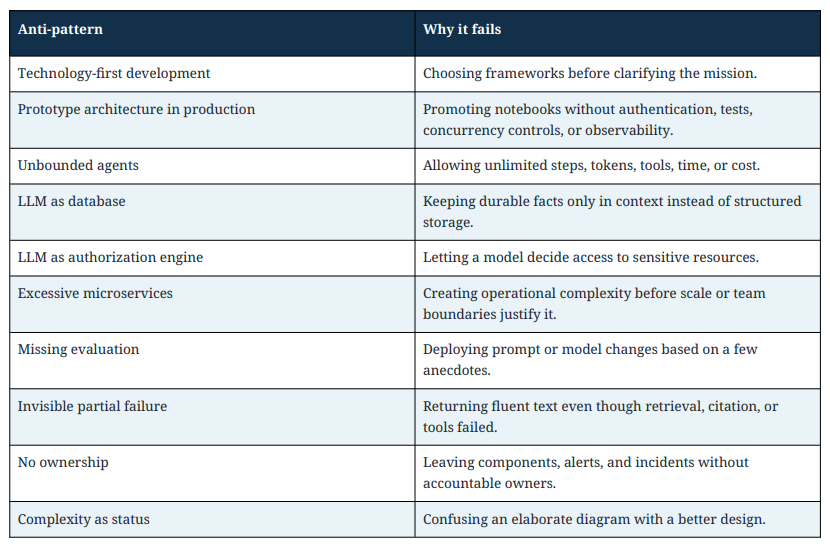

* 27.2 Pre-build checklist:
    - Is the user problem measureable and important?
    - Is AI actually required, or would deterministic software be better?
    - Are the system boundary and trust boundaries explicit?
    - Are state, interfaces, timeouts, retries, and idempotency designed?
    - Are data ownership, quality, freshness, and leagl use understood?
    - Are high-risk actions protected by deterministic authorization and approval?
    - Are end-to-end metrics, local diagnostics, and rollback plans defined?
    - Is cost per task estimated under expected and peak usage?
* 27.3 Progress Indicators:

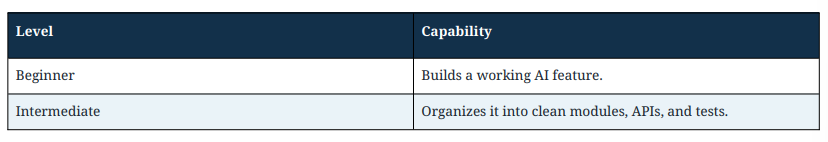
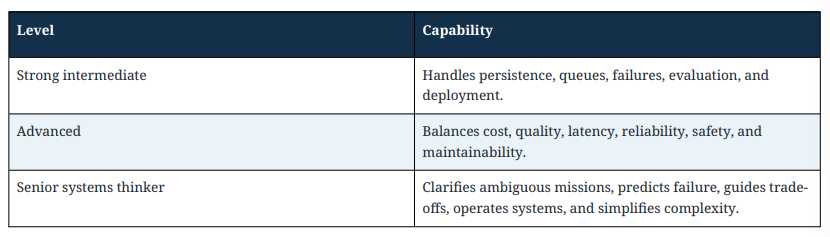


# 28. Final principles and glossary:

* 28.1 Fifteen Principles:
 1. The model is not the system.
 2. Begin with a mission and measureable requirements.
 3. Interfaces matter as much as components.
 4. Local correctness does not gurantee system correctness.
 5. Probabilstic intelligence requires deterministic constrol.
 6. Every loop needs a stopping condition.
 7. Every important requirement needs corresponding evidence.
 8. Every important requirement needs corresponding evidence.
 9. Every high-risk action needs authorization and often human approval.
 10. Every production system needs observability.
 11. Every architecture is a set of trade-offs.
 12. Simplicity is an advanced engineering achievemnet.
 13. Creativity grows when constraints, modularity, and feedback are designed well.
 14. Build systems that can explain, recover, evolve, and eventually be replaced.
 15. Think like a builder, tester, operator, attacker, user, and architect at the same time.



* 28.2 Compact glossary:

 - Architecture: The high-level organization of components, interfaces, constraints, and decisions.
 - Backpressure: Mechanisms that prevent producers from overwhelming consumers.
 - Contract: A defined promise about inputs, outputs, errors, limits, and behaviour.
 - Coupling : The degree of dependency between components.
 - Cohesion: How strongly responsibilities inside one component belong together.
 - Emergence: System behaviour created by interactions rather than one intended effect.
 - Latency: Time required to complete or begin responding to an operation.
 - Observability: Ability to understand internal behaviour from system signals.
 - Resilience: Abitlity to absorb, recover from, or adapt to failure.
 - SLO : A measureable target for a service-level indicator.
 - State: Information retained acrross operations or workflow steps.
 - Throughput: Amount of work completed per unit time.
 - Trust boundary: A point where data or contrl moves between different trust levels.
 - Validation: Evidence that the system solves the right user problem.
 - Verification: Evidence that the system matches its specification.

```
Closing Transformation:
A top AI engineer does not merely make models respond. They design intelligent systems that create reliable value, expose their behaviour, recover from failure, respect human and security boundaries, and improve through disciplined evidence.
```


# Appendix A: One-page architecture review checklist:

* Mission and stakeholders are explicit.
* Functional and non-functional requirements are measureable.
* System and trust boundaries are documented.
* Components have focused responsibilities and named owners.
* Interfaces define schemas, errors, timeouts, versions, and limits.
* State ownership, retention, deletion, and concurrency are designed.
* Probabilistic outputs are validated before consequential actions.
* All loops, retries, tokens, time, and cost are bounded.
* External side effects are idempotent or transactionally protected.
* Fallback and graceful-degradation behaviour is defined.
* End-to-end latency and capacity budgets are estimated.
* Logs, metrics, traces, and evaluation signals are specified.
* Threats, permissions, PII, and audit requirements are addressed.
* High-risk actions require deterministic authorization and approval.
* Deployment, rollback, incident response, and evolution are planned.

# Appendix B: Recommended project repository structure:
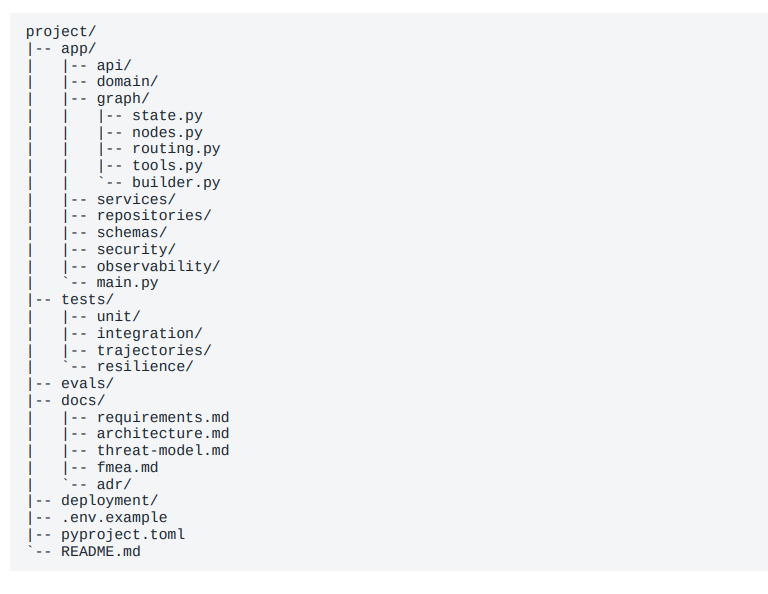 





